# The Standard Atmosphere

Lecture 3 and Table C.2 of the reference textbook tabulates the 1976 U.S. Standard Atmosphere.

## Tasks:

1. Build the atmosphere from 1 km below sea level up to 80 km using ambience, and write it to a CSV.

2. Plot temperature, gravity, pressure, density and dynamic viscosity against altitude.

3. Compare against pyatmos.

4. Build the atmosphere will high altitudes using pyatmos.

In [1]:
# pip install ambiance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ambiance import Atmosphere

In [2]:
# Provide altitude in m
z = np.arange(-1000, 80100, 100)       

# Call atmosphere
atm = Atmosphere(z)

In [3]:
# Create dataframe

df = pd.DataFrame({
    'Altitude (m)': z,
    'Temperature (deg C)': atm.temperature - 273.15,
    'Gravity (m/s2)': atm.grav_accel,
    'Pressure (N/m2)': atm.pressure,
    'Density (kg/m3)': atm.density,
    'Dynamic Viscosity (N*s/m2)': atm.dynamic_viscosity,
})

df.to_csv('standard_atmosphere_full.csv', index=False)

#df.head()

## Plots

Altitude on the vertical axis, in km.

In [4]:
# Pass to arrays
temp = np.array(df['Temperature (deg C)'])
grav = np.array(df['Gravity (m/s2)'])
pres = np.array(df['Pressure (N/m2)']/1e3)
dens = np.array(df['Density (kg/m3)'])
visc = np.array(df['Dynamic Viscosity (N*s/m2)']*1e5)

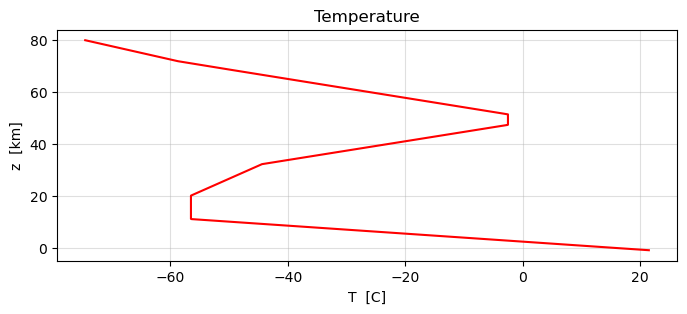

In [5]:
plt.figure(figsize=(8, 3))

plt.plot(temp, z/1.e3, color="red")

plt.xlabel("T  [C]")
plt.ylabel("z  [km]")
plt.title("Temperature")
plt.grid(alpha=0.4)

plt.show()

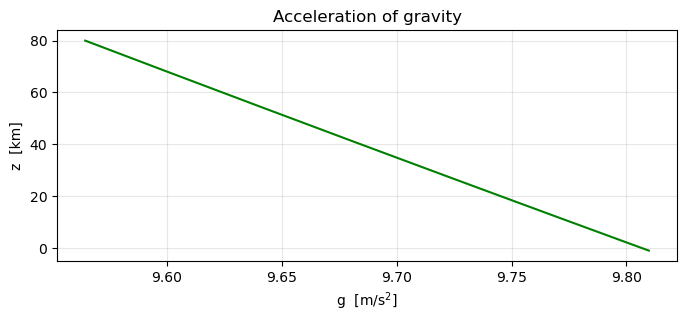

In [6]:
plt.figure(figsize=(8, 3))

plt.plot(grav, z/1e3, color="green")

plt.xlabel("g  [m/s$^2$]")
plt.ylabel("z  [km]")
plt.title("Acceleration of gravity")
plt.grid(alpha=0.3)

plt.show()

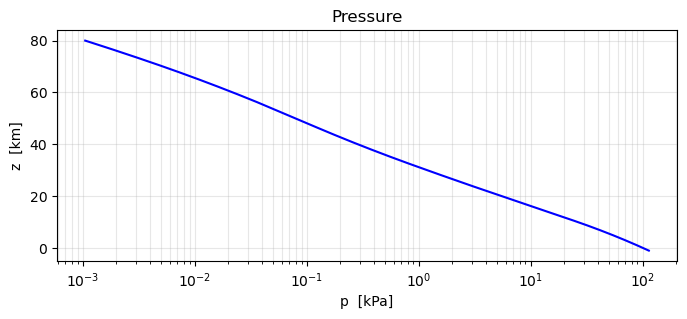

In [7]:
plt.figure(figsize=(8, 3))

plt.plot(pres, z/1e3, color="blue")

plt.xscale("log")
plt.xlabel("p  [kPa]")
plt.ylabel("z  [km]")
plt.title("Pressure")
plt.grid(alpha=0.3, which="both")

plt.show()

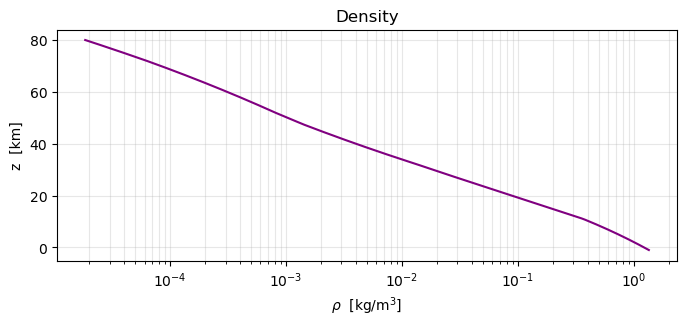

In [8]:
plt.figure(figsize=(8, 3))

plt.plot(dens, z/1e3, color="purple")

plt.xscale("log")
plt.xlabel(r"$\rho$  [kg/m$^3$]")
plt.ylabel("z  [km]")
plt.title("Density")
plt.grid(alpha=0.3, which="both")

plt.show()

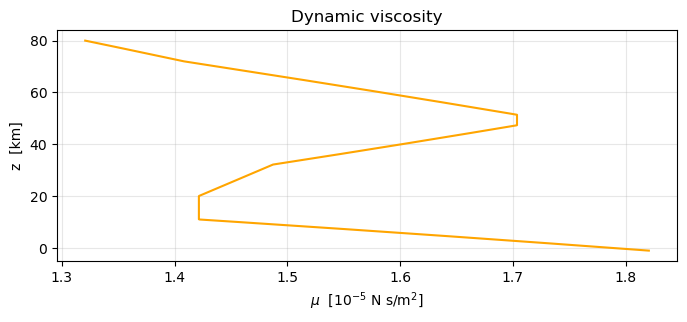

In [9]:
plt.figure(figsize=(8, 3))

plt.plot(visc, z/1e3, color="orange")

plt.xlabel(r"$\mu$  [$10^{-5}$ N s/m$^2$]")
plt.ylabel("z  [km]")
plt.title("Dynamic viscosity")
plt.grid(alpha=0.3)

plt.show()

### Observations:

- Temperature falls at 6.5 K/km through the troposphere, is constant through the lower stratosphere, then rises again: viscosity follows it, since $\mu$ depends on temperature alone.

- Pressure and density fall by five decades (dex.) over 80 km, close to straight lines on the log axis.

- Gravity drops by 2.5% over the same range, which is why the textbook treats $g$ as constant.

# Comparison with the `pyatmos` database:

`pyatmos.coesa76` implements the same 1976 model.

Overplot its temperature, pressure and density on ours, from sea level up.

In [10]:
# pip install pyatmos

import os
import pyatmos

The EOP file 'finals2000A.all' in /Users/wbandabarragan/src/iers/ is already the latest.
The Leap Second file 'Leap_Second.dat' in /Users/wbandabarragan/src/iers/ is already the latest.


In [11]:
# coesa76 is static, skip the IERS download on import
os.environ["ENABLE_IERS_LOAD"] = "false"    

# Masking negative elevations from ambience
mask = z >= 0

# pyatmos takes kilometres
z_km = z[mask] / 1e3                        

# Data object: atmo.T [K], atmo.P [N/m2], atmo.rho [kg/m3]
atmo = pyatmos.coesa76(z_km)                

T_amb = np.array(df['Temperature (deg C)'].values[mask])
p_amb = np.array(df['Pressure (N/m2)'].values[mask])
r_amb = np.array(df['Density (kg/m3)'].values[mask])

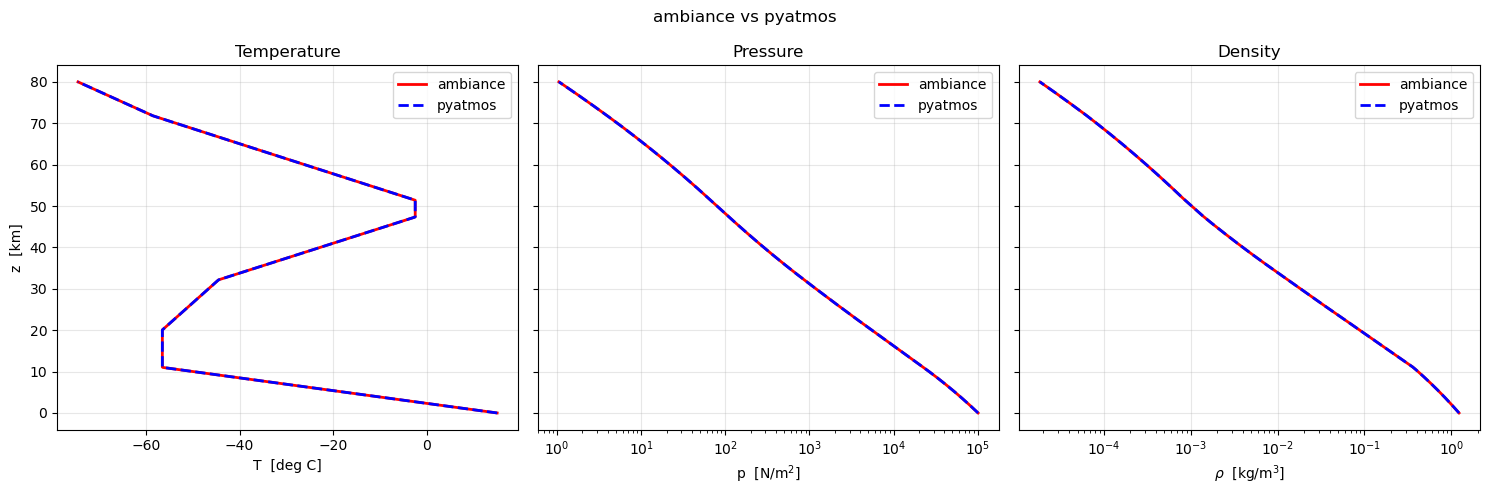

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axs[0].plot(T_amb, z_km, color="red", lw=2, label="ambiance")
axs[0].plot(atmo.T - 273.15, z_km, color="blue", ls="--", lw=2, label="pyatmos")
axs[0].set_xlabel("T  [deg C]")
axs[0].set_ylabel("z  [km]")
axs[0].set_title("Temperature")

axs[1].semilogx(p_amb, z_km, color="red", lw=2, label="ambiance")
axs[1].semilogx(atmo.P, z_km, color="blue", ls="--", lw=2, label="pyatmos")
axs[1].set_xlabel("p  [N/m$^2$]")
axs[1].set_title("Pressure")

axs[2].semilogx(r_amb, z_km, color="red", lw=2, label="ambiance")
axs[2].semilogx(atmo.rho, z_km, color="blue", ls="--", lw=2, label="pyatmos")
axs[2].set_xlabel(r"$\rho$  [kg/m$^3$]")
axs[2].set_title("Density")

for ax in axs:
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("ambiance vs pyatmos")
plt.tight_layout()

plt.show()

## ``pyatmos`` has upper atmosphere values:

- `coesa76` runs to 1000 km. 

- Temperature in kelvin from here on: above 100 km it is the kinetic temperature of a very rarefied gas, not something a thermometer reads.

In [13]:
# New vertical axis in km
z_high = np.arange(0, 1001, 1.0)            

# Data object
high = pyatmos.coesa76(z_high)


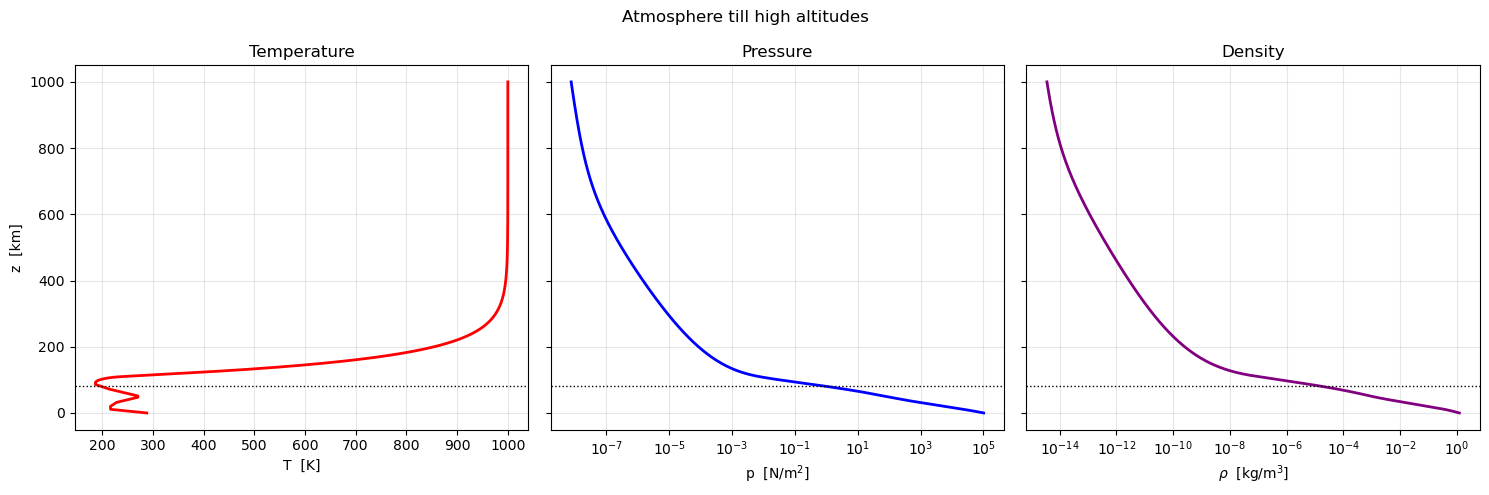

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axs[0].plot(high.T, z_high, color="red", lw=2)
axs[0].set_xlabel("T  [K]")
axs[0].set_ylabel("z  [km]")
axs[0].set_title("Temperature")

axs[1].semilogx(high.P, z_high, color="blue", lw=2)
axs[1].set_xlabel("p  [N/m$^2$]")
axs[1].set_title("Pressure")

axs[2].semilogx(high.rho, z_high, color="purple", lw=2)
axs[2].set_xlabel(r"$\rho$  [kg/m$^3$]")
axs[2].set_title("Density")

for ax in axs:
    ax.axhline(80, color="k", ls=":", lw=1)
    ax.grid(alpha=0.3)

plt.suptitle("Atmosphere till high altitudes")
plt.tight_layout()

plt.show()

### Observations:

- Temperature reaches its minimum, 187 K, at the mesopause near 87 km, then climbs to about 1000 K in the thermosphere and flattens.

- Over the same range pressure falls 13 dex. and density 14.5 dex.

- At 400 km, where the ISS orbits, the density is still $3 \times 10^{-12}\,\rm kg/m^3$, which is what makes its orbit decay.